# Leveraging Machine Learning for Personalised Voice Bundle Recommendations
## A Case Study of Airtel Uganda Limited — Real Data Analysis
**Author:** Bisimbeko Remmy | **Reg No:** J24M19/011 | Uganda Christian University  
**Data period:** February 1 – April 30, 2026 | **Geography:** Kampala, Central 1, Central 2  
**GitHub:** https://github.com/RemmyBisimbeko/Data-Science/tree/main/SEM%204/Thesis

| Section | Content |
|---------|---------|
| 1 | Setup & Library Imports |
| 2 | Data Loading (with progress + timing) |
| 3 | Data Merging & Integration |
| 4 | Feature Engineering |
| 5 | Exploratory Data Analysis |
| 6 | **Objective 1** — Statistical Tests |
| 7 | **Objective 2** — Model Training & Evaluation |
| 8 | **Objective 3** — Business Impact |


## Section 1: Setup & Library Imports

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os
from scipy.stats import spearmanr, f_oneway, chi2_contingency
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (f1_score, precision_score, recall_score,
                              accuracy_score, classification_report)
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')

try:
    from xgboost import XGBClassifier
    XGBOOST = True
    print("✅ XGBoost available")
except:
    XGBOOST = False
    print("⚠️  XGBoost not available — Random Forest will be primary model")

try:
    from imblearn.over_sampling import SMOTE
    SMOTE_OK = True
    print("✅ SMOTE available")
except:
    SMOTE_OK = False
    print("⚠️  SMOTE not available")

print("✅ All core libraries loaded")

✅ XGBoost available
✅ SMOTE available
✅ All core libraries loaded


## Section 2: Data Loading (with progress and timing)

In [32]:
def normalise_msisdn(series):
    """
    Normalise Ugandan phone numbers to 9-digit local format.
    Handles: 256XXXXXXXXX (international) and 7XXXXXXXX (local)
    """
    s = series.astype(str).str.strip()
    # Remove country code 256 prefix → leaves 9 digits starting with 7
    s = s.apply(lambda x: x[3:] if x.startswith('256') and len(x) == 12 else x)
    # Ensure 9 digits (some start with just 7)
    s = s.apply(lambda x: x if len(x) == 9 else x.lstrip('0'))
    return s

def load_excel_sheets(filepath, sheets=None, label=""):
    """Load all sheets from an Excel file with progress and timing."""
    t_total = time.time()
    xl = pd.ExcelFile(filepath)
    sheet_list = sheets if sheets else xl.sheet_names
    dfs = []
    print(f"\n📂 Loading {label} ({os.path.basename(filepath)})")
    print(f"   Sheets found: {xl.sheet_names}")
    for sh in sheet_list:
        t0 = time.time()
        try:
            df = pd.read_excel(filepath, sheet_name=sh)
            elapsed = time.time() - t0
            print(f"   ✅ Sheet '{sh}': {len(df):,} rows × {df.shape[1]} cols  [{elapsed:.1f}s]")
            dfs.append(df)
        except Exception as e:
            print(f"   ❌ Sheet '{sh}': {e}")
    total_elapsed = time.time() - t_total
    combined = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()
    print(f"   → Combined: {len(combined):,} rows  [total {total_elapsed:.1f}s]")
    return combined

print("=" * 60)
print("DATA LOADING — Airtel Uganda Research Dataset")
print("Period: February 1 – April 30, 2026")
print("=" * 60)

DATA LOADING — Airtel Uganda Research Dataset
Period: February 1 – April 30, 2026


In [33]:
# ── LOAD TARGET VARIABLE ─────────────────────────────────────────────────────
t0 = time.time()
TARGET = pd.read_csv("TARGET_VARIABLE.csv")
TARGET["PRICE"] = pd.to_numeric(
    TARGET["PRICE"].astype(str).str.replace(",","").str.strip(), errors="coerce")
TARGET["BUNDLE_VALIDITY_DAYS"] = pd.to_numeric(TARGET["BUNDLE_VALIDITY_DAYS"], errors="coerce")
TARGET["BUNDLE_ID"]       = TARGET["BUNDLE_ID"].astype(str).str.strip()
TARGET["BUNDLE_TYPE"]     = TARGET["BUNDLE_TYPE"].astype(str).str.strip()
TARGET["BUNDLE_CATEGORY"] = TARGET["BUNDLE_CATEGORY"].astype(str).str.strip()

# Filter: BUNDLE_TYPE = Voice or Combo  AND  BUNDLE_CATEGORY = Voice_OM, Combo, or VMP
VOICE_BUNDLES = TARGET[
    TARGET["BUNDLE_TYPE"].str.upper().isin(["VOICE", "COMBO"]) &
    TARGET["BUNDLE_CATEGORY"].isin(["Voice_OM", "Combo", "VMP"])
].copy()

VOICE_BUNDLE_IDS = set(VOICE_BUNDLES["BUNDLE_ID"].astype(str))

print(f"📂 TARGET_VARIABLE.csv [{time.time()-t0:.1f}s]")
print(f"   ✅ {len(TARGET):,} total | {len(VOICE_BUNDLES):,} voice/combo bundles")
print(f"   Bundle types:    {VOICE_BUNDLES['BUNDLE_TYPE'].value_counts().to_dict()}")
print(f"   Bundle category: {VOICE_BUNDLES['BUNDLE_CATEGORY'].value_counts().to_dict()}")
print(f"   Price range:     {VOICE_BUNDLES['PRICE'].min():,.0f} – {VOICE_BUNDLES['PRICE'].max():,.0f} UGX")
print(f"   Unique bundle IDs: {len(VOICE_BUNDLE_IDS):,}")

📂 TARGET_VARIABLE.csv [0.0s]
   ✅ 1,905 total | 738 voice/combo bundles
   Bundle types:    {'Voice': 571, 'Combo': 158, 'COMBO': 9}
   Bundle category: {'Voice_OM': 539, 'Combo': 152, 'VMP': 47}
   Price range:     0 – 3,000,000 UGX
   Unique bundle IDs: 738


In [34]:
# ── LOAD LOCATION DETAILS ─────────────────────────────────────────────────────
t0 = time.time()
LOCATIONS = pd.read_excel('LOCATION_DETAILS.xlsx')
LOCATIONS['SITE_CODE'] = LOCATIONS['SITE_CODE'].astype(str).str.strip()
print(f"\n📂 Loading LOCATION_DETAILS.xlsx [{time.time()-t0:.1f}s]")
print(f"   ✅ {len(LOCATIONS):,} network sites")
print(f"   Regions: {LOCATIONS['REGION'].value_counts().to_dict()}")


📂 Loading LOCATION_DETAILS.xlsx [0.5s]
   ✅ 3,697 network sites
   Regions: {'KAMPALA': 719, 'EAST 1': 641, 'CENTRAL 1': 571, 'CENTRAL 2': 434, 'WEST 2': 380, 'EAST 2': 342, 'NORTH': 271, 'WEST 1': 196, 'WESTNILE': 140, 0: 3}


In [35]:
# ── LOAD CUSTOMER PROFILE (4 sheets) ─────────────────────────────────────────
CUSTOMERS_RAW = load_excel_sheets('CUSTOMER_PROFILE.xlsx', label="CUSTOMER_PROFILE")
CUSTOMERS_RAW['PHONE_NUMBER'] = normalise_msisdn(CUSTOMERS_RAW['PHONE_NUMBER'])
CUSTOMERS_RAW['SITE_CODE'] = CUSTOMERS_RAW['SITE_CODE'].astype(str).str.strip()

# Deduplicate — keep row with highest TOTAL_REVENUE per subscriber
CUSTOMERS = (CUSTOMERS_RAW
             .sort_values('TOTAL_REVENUE', ascending=False)
             .drop_duplicates(subset='PHONE_NUMBER', keep='first')
             .reset_index(drop=True))

print(f"\n   After deduplication: {len(CUSTOMERS):,} unique subscribers")
print(f"   Gender:   {CUSTOMERS['GENDER'].value_counts().to_dict()}")
print(f"   Segments: {CUSTOMERS['VALUESEGMENT'].value_counts().to_dict()}")
print(f"   Regions:  {CUSTOMERS['REGION'].value_counts().to_dict()}")


📂 Loading CUSTOMER_PROFILE (CUSTOMER_PROFILE.xlsx)
   Sheets found: ['Sheet1', 'Sheet2', 'Sheet3', 'Sheet4']
   ✅ Sheet 'Sheet1': 1,048,575 rows × 14 cols  [65.8s]
   ✅ Sheet 'Sheet2': 1,048,575 rows × 14 cols  [33.0s]
   ✅ Sheet 'Sheet3': 921,766 rows × 14 cols  [29.2s]
   ✅ Sheet 'Sheet4': 68,373 rows × 14 cols  [2.2s]
   → Combined: 3,087,289 rows  [total 130.2s]

   After deduplication: 1,514,566 unique subscribers
   Gender:   {'F': 801921, 'M': 712645}
   Segments: {'Silver': 776970, 'Gold': 256924, 'New': 200083, 'Super Gold': 84316, 'Ivory': 70267, 'Platinum': 39249, 'New Ultra': 31057, '[NULL]': 12230, 'Diamond': 34}
   Regions:  {'CENTRAL 1': 570614, 'KAMPALA': 491458, 'CENTRAL 2': 452494}


In [ ]:
# ── LOAD BUNDLE CONSUMPTION (BUNDLE_CONSUMPTION.xlsx + BUNDLE_CONSUMPTION_2.xlsx) ──
# Both files contain daily voice usage per subscriber per site
# Sheets are named by MSISDN prefix cluster (e.g. TRX - 25674)

bc_all = []
for filepath in ['BUNDLE_CONSUMPTION.xlsx', 'BUNDLE_CONSUMPTION_2.xlsx']:
    if not os.path.exists(filepath):
        print(f"⚠️  {filepath} not found — skipping (upload to notebook folder)")
        continue
    df_bc = load_excel_sheets(filepath, label=filepath.replace('.xlsx',''))
    bc_all.append(df_bc)

if not bc_all:
    raise FileNotFoundError("No BUNDLE_CONSUMPTION files found. Upload both xlsx files.")

CONSUMPTION_RAW = pd.concat(bc_all, ignore_index=True)

# ── FIX COLUMN NAME ───────────────────────────────────────────────────────────
# '_ONNET_MINUTES_USED' is a known export error — should be 'IC_ONNET_MINUTES_USED'
if '_ONNET_MINUTES_USED' in CONSUMPTION_RAW.columns:
    CONSUMPTION_RAW = CONSUMPTION_RAW.rename(
        columns={'_ONNET_MINUTES_USED': 'IC_ONNET_MINUTES_USED'})
    print("   ✅ Column renamed: _ONNET_MINUTES_USED → IC_ONNET_MINUTES_USED")

# ── COLUMN SEMANTICS ──────────────────────────────────────────────────────────
# OG (Outgoing): calls FROM Airtel subscribers TO non-Airtel numbers
# IC (Incoming): calls FROM non-Airtel numbers TO Airtel subscribers
# ONNET:  calls between Airtel subscribers (same network, no OG/IC fee)
# OFFNET: calls to/from other networks (MTN, UG Telcom, Lyca, K2 etc.)
# INTL:   international calls

# ── NORMALISE MSISDN ──────────────────────────────────────────────────────────
CONSUMPTION_RAW['PHONE_NUMBER'] = normalise_msisdn(CONSUMPTION_RAW['SERVEDMSISDN'])
CONSUMPTION_RAW['SITE_CODE'] = CONSUMPTION_RAW['SITE_CODE'].astype(str).str.strip()
CONSUMPTION_RAW['EVENTDATE'] = pd.to_datetime(CONSUMPTION_RAW['EVENTDATE'], errors='coerce')

print(f"\n   ✅ Combined consumption: {len(CONSUMPTION_RAW):,} rows")
print(f"   Date range: {CONSUMPTION_RAW['EVENTDATE'].min().date()} → {CONSUMPTION_RAW['EVENTDATE'].max().date()}")
print(f"   Unique subscribers: {CONSUMPTION_RAW['PHONE_NUMBER'].nunique():,}")
print(f"   Columns: {CONSUMPTION_RAW.columns.tolist()}")


📂 Loading BUNDLE_CONSUMPTION (BUNDLE_CONSUMPTION.xlsx)
   Sheets found: ['TRX - 25674', 'TRX - 25675', 'TRX - 25670', 'TRX - 25673']
   ✅ Sheet 'TRX - 25674': 500,000 rows × 13 cols  [14.7s]
   ✅ Sheet 'TRX - 25675': 500,000 rows × 13 cols  [15.0s]
   ✅ Sheet 'TRX - 25670': 500,000 rows × 13 cols  [14.8s]
   ✅ Sheet 'TRX - 25673': 500,000 rows × 13 cols  [14.8s]
   → Combined: 2,000,000 rows  [total 59.3s]

📂 Loading BUNDLE_CONSUMPTION_2 (BUNDLE_CONSUMPTION_2.xlsx)
   Sheets found: ['TRX_SAMPLE_1', 'TRX_SAMPLE_2', 'TRX_SAMPLE_3', 'TRX_SAMPLE_4', 'TRX_SAMPLE_5']
   ✅ Sheet 'TRX_SAMPLE_1': 1,048,575 rows × 13 cols  [30.7s]
   ✅ Sheet 'TRX_SAMPLE_2': 1,048,575 rows × 13 cols  [30.6s]
   ✅ Sheet 'TRX_SAMPLE_3': 1,048,575 rows × 13 cols  [30.5s]
   ✅ Sheet 'TRX_SAMPLE_4': 1,048,575 rows × 13 cols  [30.7s]
   ✅ Sheet 'TRX_SAMPLE_5': 1,048,575 rows × 13 cols  [31.4s]
   → Combined: 5,242,875 rows  [total 154.0s]

   ✅ Combined consumption: 7,242,875 rows
   Date range: 2026-02-01 → 2026-04-3

---
## Section 3: Data Merging & Integration

In [37]:
# ── AGGREGATE CONSUMPTION PER SUBSCRIBER ──────────────────────────────────────
t0 = time.time()
print("Aggregating consumption per subscriber...")

CONSUMPTION_AGG = CONSUMPTION_RAW.groupby('PHONE_NUMBER', as_index=False).agg(
    TOTAL_OG_MINUTES       = ('TOTAL_OG_MINUTES_USED',         'sum'),
    TOTAL_IC_MINUTES       = ('TOTAL_IC_MINUTES_USED',         'sum'),
    OG_ONNET_MINUTES       = ('OG_ONNET_MINUTES_USED',         'sum'),
    OG_OFFNET_MINUTES      = ('OG_OFFNET_MINUTES_USED',        'sum'),
    OG_INTL_MINUTES        = ('OG_INTERNATIONAL_MINUTES_USED', 'sum'),
    OG_UNCLASSIFIED        = ('OG_UNCLASSIFIED_MINUTES_USED',  'sum'),
    IC_ONNET_MINUTES       = ('IC_ONNET_MINUTES_USED',         'sum'),
    IC_OFFNET_MINUTES      = ('IC_OFFNET_MINUTES_USED',        'sum'),
    IC_INTL_MINUTES        = ('IC_INTERNATIONAL_MINUTES_USED', 'sum'),
    IC_UNCLASSIFIED        = ('IC_UNCLASSIFIED_MINUTES_USED',  'sum'),
    ACTIVE_DAYS            = ('EVENTDATE',                     'nunique'),
    FIRST_ACTIVITY_DATE    = ('EVENTDATE',                     'min'),
    LAST_ACTIVITY_DATE     = ('EVENTDATE',                     'max'),
)

# Derived ratios (avoid divide-by-zero with clip)
tot = CONSUMPTION_AGG['TOTAL_OG_MINUTES'].clip(lower=1)
CONSUMPTION_AGG['ONNET_OG_RATIO']  = (CONSUMPTION_AGG['OG_ONNET_MINUTES']  / tot).round(4)
CONSUMPTION_AGG['OFFNET_OG_RATIO'] = (CONSUMPTION_AGG['OG_OFFNET_MINUTES'] / tot).round(4)
CONSUMPTION_AGG['INTL_OG_RATIO']   = (CONSUMPTION_AGG['OG_INTL_MINUTES']   / tot).round(4)

# International caller/receiver flags
CONSUMPTION_AGG['MAKES_INTL_CALLS']    = (CONSUMPTION_AGG['OG_INTL_MINUTES'] > 0).astype(int)
CONSUMPTION_AGG['RECEIVES_INTL_CALLS'] = (CONSUMPTION_AGG['IC_INTL_MINUTES'] > 0).astype(int)
CONSUMPTION_AGG['IS_INTL_USER']        = (
    (CONSUMPTION_AGG['OG_INTL_MINUTES'] > 0) |
    (CONSUMPTION_AGG['IC_INTL_MINUTES'] > 0)
).astype(int)

# Avg daily outgoing minutes
CONSUMPTION_AGG['AVG_DAILY_OG_MINS'] = (
    CONSUMPTION_AGG['TOTAL_OG_MINUTES'] /
    CONSUMPTION_AGG['ACTIVE_DAYS'].clip(lower=1)
).round(2)

print(f"✅ Consumption aggregated: {len(CONSUMPTION_AGG):,} unique subscribers [{time.time()-t0:.1f}s]")
print(CONSUMPTION_AGG[['TOTAL_OG_MINUTES','TOTAL_IC_MINUTES','AVG_DAILY_OG_MINS',
                         'ACTIVE_DAYS','MAKES_INTL_CALLS']].describe().round(2))

Aggregating consumption per subscriber...
✅ Consumption aggregated: 2,365,697 unique subscribers [5.5s]
       TOTAL_OG_MINUTES  TOTAL_IC_MINUTES  AVG_DAILY_OG_MINS  ACTIVE_DAYS  \
count      2365697.0000      2365697.0000       2365697.0000 2365697.0000   
mean            63.5000           37.0200            30.8200       1.8700   
std            105.7100           75.4600            43.3900       1.3000   
min              1.0000            0.0000             1.0000       1.0000   
25%              9.0000            2.0000             7.0000       1.0000   
50%             27.0000           12.0000            18.0000       1.0000   
75%             72.0000           40.0000            38.0000       2.0000   
max           5379.0000         6063.0000          2448.0000      21.0000   

       MAKES_INTL_CALLS  
count      2365697.0000  
mean             0.0000  
std              0.0600  
min              0.0000  
25%              0.0000  
50%              0.0000  
75%              0.0

In [38]:
# ── ENRICH CUSTOMERS WITH LOCATION ────────────────────────────────────────────
t0 = time.time()
CUSTOMERS_LOC = CUSTOMERS.merge(
    LOCATIONS[['SITE_CODE','TOWN_NAME','STATE','DISTRICT',
               'LATITUDE','LONGITUDE','CLUSTER']],
    on='SITE_CODE', how='left'
)
print(f"✅ Location enrichment complete [{time.time()-t0:.1f}s]")
print(f"   Location match rate: {CUSTOMERS_LOC['TOWN_NAME'].notna().mean()*100:.1f}%")

# ── MERGE WITH CONSUMPTION ────────────────────────────────────────────────────
t0 = time.time()
MASTER = CUSTOMERS_LOC.merge(CONSUMPTION_AGG, on='PHONE_NUMBER', how='left')
print(f"✅ Master dataset built: {MASTER.shape} [{time.time()-t0:.1f}s]")
print(f"   Consumption match rate: {MASTER['TOTAL_OG_MINUTES'].notna().mean()*100:.1f}%")
print(f"   Columns: {MASTER.columns.tolist()}")

✅ Location enrichment complete [0.7s]
   Location match rate: 100.0%
✅ Master dataset built: (1514566, 40) [1.7s]
   Consumption match rate: 100.0%
   Columns: ['PHONE_NUMBER', 'DEVICE_TYPE', 'HANDSET_TYPE', 'SITE_CODE', 'REGION', 'GENDER', 'REC_30_DAYS', 'QREC', 'AGE', 'TENURE_DAYS', 'VALUESEGMENT', 'TOTAL_REVENUE', 'MOBILE_MONEY', 'CALLS', 'TOWN_NAME', 'STATE', 'DISTRICT', 'LATITUDE', 'LONGITUDE', 'CLUSTER', 'TOTAL_OG_MINUTES', 'TOTAL_IC_MINUTES', 'OG_ONNET_MINUTES', 'OG_OFFNET_MINUTES', 'OG_INTL_MINUTES', 'OG_UNCLASSIFIED', 'IC_ONNET_MINUTES', 'IC_OFFNET_MINUTES', 'IC_INTL_MINUTES', 'IC_UNCLASSIFIED', 'ACTIVE_DAYS', 'FIRST_ACTIVITY_DATE', 'LAST_ACTIVITY_DATE', 'ONNET_OG_RATIO', 'OFFNET_OG_RATIO', 'INTL_OG_RATIO', 'MAKES_INTL_CALLS', 'RECEIVES_INTL_CALLS', 'IS_INTL_USER', 'AVG_DAILY_OG_MINS']


---
## Section 4: Feature Engineering
Deriving behavioral features from merged data.

In [39]:
# ── PURCHASE TIMING FILES (load if available) ─────────────────────────────────
PURCHASES = None
purchase_files = [
    ('PURCHASE_TIMING_FEB.xlsx',   'February'),
    ('PURCHASE_TIMING_MARCH.xlsx', 'March'),
    ('PURCHASE_TIMING_APRIL.xlsx', 'April'),
]

for filepath, month in purchase_files:
    if not os.path.exists(filepath):
        print(f"⚠️  {filepath} not found — skipping")
        continue
    
    xl = pd.ExcelFile(filepath)
    # Exclude loan tab — load all date tabs
    data_sheets = [s for s in xl.sheet_names if s not in ['Loan Bundle Feb-Apr']]
    month_df = load_excel_sheets(filepath, sheets=data_sheets, label=f"Purchase Timing {month}")
    
    if len(month_df) > 0:
        PURCHASES = month_df if PURCHASES is None else pd.concat([PURCHASES, month_df], ignore_index=True)

# Also load loan bundles
loan_file = 'PURCHASE_TIMING_FEB.xlsx'
if os.path.exists(loan_file):
    try:
        xl = pd.ExcelFile(loan_file)
        if 'Loan Bundle Feb-Apr' in xl.sheet_names:
            t0 = time.time()
            loans = pd.read_excel(loan_file, sheet_name='Loan Bundle Feb-Apr')
            print(f"\n   ✅ Loan Bundle tab: {len(loans):,} rows [{time.time()-t0:.1f}s]")
            if PURCHASES is not None:
                PURCHASES = pd.concat([PURCHASES, loans], ignore_index=True)
    except Exception as e:
        print(f"   Loan tab: {e}")

if PURCHASES is not None:
    PURCHASES['Charged_Number'] = normalise_msisdn(PURCHASES['Charged_Number'])
    PURCHASES['BUNDLE_ID'] = PURCHASES['BUNDLE_ID'].astype(str).str.strip()
    PURCHASES['PURCHASE_DATE'] = pd.to_datetime(PURCHASES['PURCHASE_DATE'], errors='coerce')
    PURCHASES['BUNDLE_REVENUE'] = pd.to_numeric(PURCHASES['BUNDLE_REVENUE'], errors='coerce')
    print(f"\n✅ Total purchase transactions: {len(PURCHASES):,}")
    print(f"   Date range: {PURCHASES['PURCHASE_DATE'].min().date()} → {PURCHASES['PURCHASE_DATE'].max().date()}")
    print(f"   Unique subscribers: {PURCHASES['Charged_Number'].nunique():,}")
    print(f"   Unique bundles: {PURCHASES['BUNDLE_ID'].nunique():,}")
else:
    print("\n⚠️  No purchase timing files found — upload PURCHASE_TIMING_FEB/MARCH/APRIL.xlsx")


📂 Loading Purchase Timing February (PURCHASE_TIMING_FEB.xlsx)
   Sheets found: ['Loan Bundle Feb-Apr', '2-1', '2-2', '2-3', '2-4', '2-5', '2-6', '2-7', '2-8', '2-9', '2-10', '2-11', '2-12', '2-13', '2-14', '2-15', '2-16', '2-17', '2-18', '2-19', '2-20', '2-21', '2-22', '2-23', '2-24', '2-25', '2-26', '2-27', '2-28']
   ✅ Sheet '2-1': 633,499 rows × 9 cols  [14.6s]
   ✅ Sheet '2-2': 677,288 rows × 9 cols  [15.5s]
   ✅ Sheet '2-3': 661,284 rows × 9 cols  [15.6s]
   ✅ Sheet '2-4': 669,581 rows × 9 cols  [15.1s]
   ✅ Sheet '2-5': 663,971 rows × 9 cols  [15.1s]
   ✅ Sheet '2-6': 653,604 rows × 9 cols  [14.9s]
   ✅ Sheet '2-7': 656,045 rows × 9 cols  [14.8s]
   ✅ Sheet '2-8': 660,216 rows × 9 cols  [15.0s]
   ✅ Sheet '2-9': 678,921 rows × 9 cols  [15.2s]
   ✅ Sheet '2-10': 669,474 rows × 9 cols  [15.2s]
   ✅ Sheet '2-11': 665,687 rows × 9 cols  [15.2s]
   ✅ Sheet '2-12': 652,765 rows × 9 cols  [14.9s]
   ✅ Sheet '2-13': 687,230 rows × 9 cols  [15.9s]
   ✅ Sheet '2-14': 675,376 rows × 9 cols

In [58]:
# ── BUILD PURCHASE HISTORY FEATURES ──────────────────────────────────────────
if PURCHASES is not None:
    t0 = time.time()
    print("Building purchase history features from PURCHASE_TIMING data...")

    # ── NORMALISE PHONE NUMBERS ───────────────────────────────────────────────
    def norm_phone(s):
        s = str(s).strip()
        if s.endswith('.0'): s = s[:-2]
        if s.startswith('256') and len(s) == 12: return s[3:]
        if s.startswith('+256') and len(s) == 13: return s[4:]
        if s.startswith('0') and len(s) == 10: return s[1:]
        return s

    P = PURCHASES.copy()
    P['PHONE_NUMBER']  = P['Charged_Number'].apply(norm_phone)
    P['PURCHASE_DATE'] = pd.to_datetime(P['PURCHASE_DATE'], errors='coerce')
    P['PURCHASE_HOUR'] = pd.to_numeric(P['PURCHASE_HOUR'], errors='coerce').fillna(12)

    # ── NORMALISE BUNDLE_ID — strip .0 and whitespace ─────────────────────────
    def norm_id(x):
        s = str(x).strip()
        if s.endswith('.0'): s = s[:-2]
        return s

    P['BUNDLE_ID'] = P['BUNDLE_ID'].apply(norm_id)

    # Debug bundle ID formats
    p_bundle_sample = P['BUNDLE_ID'].dropna().head(5).tolist()
    v_bundle_sample = list(VOICE_BUNDLE_IDS)[:5]
    print(f"  PURCHASES BUNDLE_ID sample: {p_bundle_sample}")
    print(f"  VOICE_BUNDLE_IDS sample:    {v_bundle_sample}")

    # Check overlap
    overlap_phones = set(MASTER['PHONE_NUMBER'].astype(str)) & set(P['PHONE_NUMBER'].astype(str))
    overlap_bundles = set(P['BUNDLE_ID']) & VOICE_BUNDLE_IDS
    print(f"  Phone overlap:  {len(overlap_phones):,}")
    print(f"  Bundle overlap: {len(overlap_bundles):,} of {len(VOICE_BUNDLE_IDS):,} voice bundles")

    # ── FILTER TO VOICE BUNDLES — with fallback if no overlap ────────────────
    P_voice = P[P['BUNDLE_ID'].isin(VOICE_BUNDLE_IDS)].copy()
    print(f"  Rows after voice filter: {len(P_voice):,}")

    if len(P_voice) == 0:
        print("  ⚠️  Voice bundle filter returned 0 rows.")
        print(f"  Using ALL purchase records instead (no bundle filter)")
        P_voice = P.copy()  # fallback: use all purchases
    
    P = P_voice

    # Join bundle prices
    tv_ref = VOICE_BUNDLES[['BUNDLE_ID','PRICE','BUNDLE_VALIDITY_DAYS','BUNDLE_CATEGORY']].copy()
    tv_ref['BUNDLE_ID'] = tv_ref['BUNDLE_ID'].apply(norm_id)
    P = P.merge(tv_ref, on='BUNDLE_ID', how='left')
    P['BUNDLE_PRICE'] = pd.to_numeric(
        P['PRICE'].fillna(P['BUNDLE_REVENUE']), errors='coerce').fillna(0)

    END_DATE = pd.Timestamp('2026-04-30')
    DATE_30D = END_DATE - pd.Timedelta(days=30)
    DATE_60D = END_DATE - pd.Timedelta(days=60)

    P = P.sort_values(['PHONE_NUMBER','PURCHASE_DATE','PURCHASE_HOUR']).reset_index(drop=True)

    # Lag features
    P['PREV_BUNDLE_ID']     = P.groupby('PHONE_NUMBER', sort=False)['BUNDLE_ID'].shift(1)
    P['PREV_BUNDLE_PRICE']  = P.groupby('PHONE_NUMBER', sort=False)['BUNDLE_PRICE'].shift(1)
    P['BUNDLE_SWITCH_FLAG'] = (P['BUNDLE_ID'] != P['PREV_BUNDLE_ID']).astype(int)
    P['UPGRADE_FLAG']       = (P['BUNDLE_PRICE'] > P['PREV_BUNDLE_PRICE'].fillna(0)).astype(int)

    # Base aggregation
    base = P.groupby('PHONE_NUMBER', sort=False, as_index=False).agg(
        PURCHASES_TOTAL        = ('BUNDLE_ID',           'count'),
        BUNDLE_SPEND_90D       = ('BUNDLE_PRICE',        'sum'),
        LAST_BUNDLE_ID         = ('BUNDLE_ID',           'last'),
        LAST_BUNDLE_PRICE      = ('BUNDLE_PRICE',        'last'),
        MAX_BUNDLE_PRICE_EVER  = ('BUNDLE_PRICE',        'max'),
        DISTINCT_BUNDLES_TRIED = ('BUNDLE_ID',           'nunique'),
        BUNDLE_SWITCH_COUNT    = ('BUNDLE_SWITCH_FLAG',  'sum'),
        UPGRADE_COUNT          = ('UPGRADE_FLAG',        'sum'),
        AVG_PURCHASE_HOUR      = ('PURCHASE_HOUR',       'mean'),
    )
    print(f"  Base aggregation rows: {len(base):,}")

    def top_value(series, default=np.nan):
        try:
            clean = series.dropna()
            if len(clean) == 0: return default
            vals = clean.value_counts().index.tolist()
            return vals[0] if vals else default
        except Exception: return default

    most_freq_bundle  = (P.groupby('PHONE_NUMBER', sort=False)['BUNDLE_ID']
                          .apply(lambda x: top_value(x))
                          .reset_index().rename(columns={'BUNDLE_ID':'MOST_FREQ_BUNDLE_ID'}))
    most_freq_hour    = (P.groupby('PHONE_NUMBER', sort=False)['PURCHASE_HOUR']
                          .apply(lambda x: top_value(x, 12))
                          .reset_index().rename(columns={'PURCHASE_HOUR':'MOST_FREQ_HOUR'}))
    most_freq_channel = (P.groupby('PHONE_NUMBER', sort=False)['TRANSACTION_CHANNEL']
                          .apply(lambda x: top_value(x, 'USSD'))
                          .reset_index().rename(columns={'TRANSACTION_CHANNEL':'MOST_FREQ_CHANNEL'}))
    most_freq_payment = (P.groupby('PHONE_NUMBER', sort=False)['PAYMENT_CHANNEL']
                          .apply(lambda x: top_value(x, 'AM'))
                          .reset_index().rename(columns={'PAYMENT_CHANNEL':'MOST_FREQ_PAYMENT'}))

    for extra in [most_freq_bundle, most_freq_hour, most_freq_channel, most_freq_payment]:
        base = base.merge(extra, on='PHONE_NUMBER', how='left')

    p30 = (P[P['PURCHASE_DATE'] >= DATE_30D]
           .groupby('PHONE_NUMBER', sort=False, as_index=False)
           .agg(PURCHASES_LAST_30D = ('BUNDLE_ID',    'count'),
                BUNDLE_SPEND_30D   = ('BUNDLE_PRICE', 'sum')))
    p60 = (P[P['PURCHASE_DATE'] >= DATE_60D]
           .groupby('PHONE_NUMBER', sort=False, as_index=False)
           .agg(PURCHASES_LAST_60D = ('BUNDLE_ID', 'count')))

    PH = base.merge(p30, on='PHONE_NUMBER', how='left')
    PH = PH.merge(p60, on='PHONE_NUMBER', how='left')
    PH['PURCHASES_LAST_30D'] = PH['PURCHASES_LAST_30D'].fillna(0)
    PH['BUNDLE_SPEND_30D']   = PH['BUNDLE_SPEND_30D'].fillna(0)
    PH['PURCHASES_LAST_60D'] = PH['PURCHASES_LAST_60D'].fillna(0)

    PH['ARPU_30D']            = PH['BUNDLE_SPEND_30D']
    PH['ARPU_90D']            = PH['BUNDLE_SPEND_90D']
    PH['ARPU_TREND']          = (PH['ARPU_30D'] / (PH['ARPU_90D'] / 3).clip(lower=1)).round(4)
    PH['PURCHASE_FREQ_RATIO'] = (PH['PURCHASES_LAST_30D'] /
                                   PH['PURCHASES_LAST_60D'].clip(lower=1)).round(4)
    PH['BUNDLE_SWITCH_RATE']  = (PH['BUNDLE_SWITCH_COUNT'] /
                                   PH['PURCHASES_TOTAL'].clip(lower=1)).round(4)
    PH['UPGRADE_RATE']        = (PH['UPGRADE_COUNT'] /
                                   PH['PURCHASES_TOTAL'].clip(lower=1)).round(4)

    MASTER = MASTER.merge(PH, on='PHONE_NUMBER', how='left')

    matched = MASTER['PURCHASES_TOTAL'].notna().sum() if 'PURCHASES_TOTAL' in MASTER.columns else 0
    print(f"\n✅ Purchase history merged [{time.time()-t0:.1f}s]")
    print(f"   Matched: {matched:,} / {len(MASTER):,} ({matched/len(MASTER)*100:.1f}%)")
    if matched > 0:
        print(MASTER[['PURCHASES_TOTAL','BUNDLE_SPEND_90D','ARPU_TREND',
                      'PURCHASE_FREQ_RATIO','DISTINCT_BUNDLES_TRIED']].describe().round(2))

else:
    for col in ['PURCHASES_LAST_30D','PURCHASES_LAST_60D','BUNDLE_SPEND_30D',
                'BUNDLE_SPEND_90D','ARPU_30D','ARPU_90D','ARPU_TREND',
                'PURCHASE_FREQ_RATIO','LAST_BUNDLE_PRICE','MAX_BUNDLE_PRICE_EVER',
                'DISTINCT_BUNDLES_TRIED','BUNDLE_SWITCH_RATE','UPGRADE_RATE',
                'MOST_FREQ_BUNDLE_ID','AVG_PURCHASE_HOUR','MOST_FREQ_HOUR',
                'MOST_FREQ_CHANNEL','PURCHASES_TOTAL']:
        MASTER[col] = np.nan
    print("⚠️  No purchase timing files — placeholder nulls created")


Building purchase history features from PURCHASE_TIMING data...
  PURCHASES BUNDLE_ID sample: ['6071492', '6071145', '6071624', '6040360', '6071145']
  VOICE_BUNDLE_IDS sample:    ['6071332', '6071378', '6080980', '6000527', '6071623']
  Phone overlap:  1,376,175
  Bundle overlap: 267 of 738 voice bundles
  Rows after voice filter: 59,163,269
  Base aggregation rows: 2,077,965

✅ Purchase history merged [1038.1s]
   Matched: 1,374,563 / 1,471,130 (93.4%)
       PURCHASES_TOTAL  BUNDLE_SPEND_90D   ARPU_TREND  PURCHASE_FREQ_RATIO  \
count     1374563.0000      1374563.0000 1374563.0000         1374563.0000   
mean           29.3800        27494.7100       1.1500               0.5100   
std            34.0000        37726.5900       0.7500               0.2700   
min             1.0000            0.0000       0.0000               0.0000   
25%             9.0000         7600.0000       0.7000               0.3800   
50%            22.0000        18900.0000       1.0800               0.520

In [59]:
# ── DERIVE REMAINING FEATURES FROM CONSUMPTION ────────────────────────────────
t0 = time.time()

# Depletion rate = outgoing minutes / active days
MASTER['DEPLETION_RATE']   = (MASTER['TOTAL_OG_MINUTES'] /
                               MASTER['ACTIVE_DAYS'].clip(lower=1)).round(4)

# Spend efficiency
MASTER['SPEND_PER_MINUTE'] = (MASTER['TOTAL_REVENUE'] /
                               MASTER['TOTAL_OG_MINUTES'].clip(lower=1)).round(4)

# Voice call intensity
MASTER['VOICE_INTENSITY']  = (MASTER['CALLS'] /
                               MASTER['ACTIVE_DAYS'].clip(lower=1)).round(4)

# High consumer flag (top quartile of depletion)
q75 = MASTER['DEPLETION_RATE'].quantile(0.75)
MASTER['HIGH_CONSUMER_FLAG'] = (MASTER['DEPLETION_RATE'] >= q75).astype(int)

# Smartphone flag
MASTER['IS_SMARTPHONE'] = (MASTER['HANDSET_TYPE'] == 'SP').astype(int)

# Age group
MASTER['AGE_GROUP'] = pd.cut(
    pd.to_numeric(MASTER['AGE'], errors='coerce'),
    bins=[0, 25, 35, 50, 120],
    labels=['18-25', '26-35', '36-50', '50+']
)

# Spend trend from ARPU_TREND if available
if MASTER['ARPU_TREND'].notna().sum() > 100:
    MASTER['SPEND_TREND_CODE'] = pd.cut(
        MASTER['ARPU_TREND'],
        bins=[-np.inf, 0.8, 1.2, np.inf],
        labels=[0, 1, 2]  # Decreasing, Stable, Increasing
    ).astype(float)
else:
    MASTER['SPEND_TREND_CODE'] = 1.0  # Stable default

# Drop null target rows
MASTER = MASTER.dropna(subset=['VALUESEGMENT']).reset_index(drop=True)

print(f"✅ Feature engineering complete [{time.time()-t0:.1f}s]")
print(f"   Final dataset: {MASTER.shape}")
print(f"   Target distribution:")
print(MASTER['VALUESEGMENT'].value_counts().to_string())

✅ Feature engineering complete [3.9s]
   Final dataset: (1471130, 113)
   Target distribution:
VALUESEGMENT
Silver        776970
Gold          256924
New           200083
Super Gold     84316
Ivory          70267
Platinum       39249
New Ultra      31057
[NULL]         12230
Diamond           34


---
## Section 5: Exploratory Data Analysis

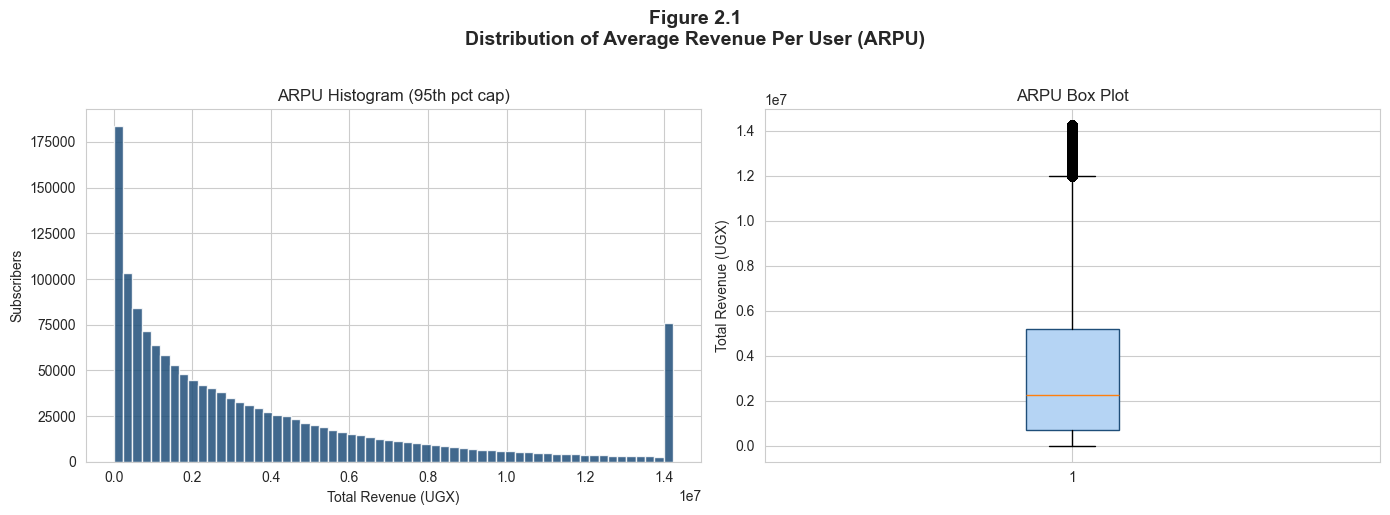

ARPU:
count     1466924.0000
mean      4069886.0000
std       5608453.0000
min             1.0000
25%        698218.0000
50%       2263992.0000
75%       5203818.0000
max     280862538.0000
Name: TOTAL_REVENUE, dtype: float64

Note. Source: Airtel Uganda subscriber data (Feb–Apr 2026).


In [60]:
# ── FIGURE 2.1: ARPU DISTRIBUTION ────────────────────────────────────────────
arpu = pd.to_numeric(MASTER['TOTAL_REVENUE'], errors='coerce').dropna()
arpu = arpu[arpu > 0]
cap95 = arpu.quantile(0.95)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(arpu.clip(upper=cap95), bins=60, color='#1F4E79', edgecolor='white', alpha=0.85)
axes[0].set_title('ARPU Histogram (95th pct cap)')
axes[0].set_xlabel('Total Revenue (UGX)')
axes[0].set_ylabel('Subscribers')

axes[1].boxplot(arpu.clip(upper=cap95), patch_artist=True,
                boxprops=dict(facecolor='#B5D4F4', color='#1F4E79'))
axes[1].set_ylabel('Total Revenue (UGX)')
axes[1].set_title('ARPU Box Plot')

fig.suptitle('Figure 2.1\nDistribution of Average Revenue Per User (ARPU)',
             fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('fig2_1_arpu_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"ARPU:\n{arpu.describe().round(0)}")
print("\nNote. Source: Airtel Uganda subscriber data (Feb–Apr 2026).")

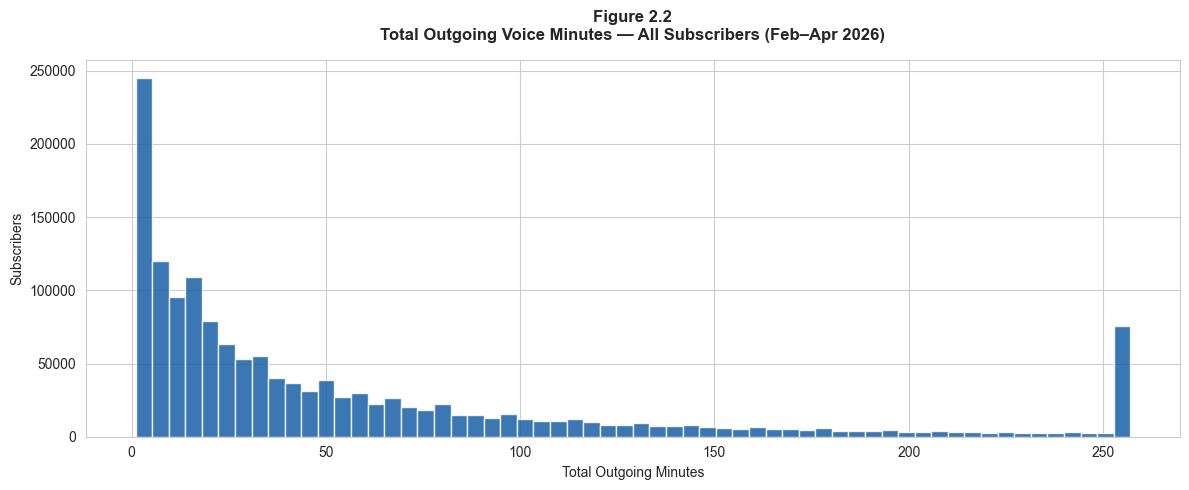

Usage:
count   1471130.0000
mean         66.2400
std         109.4400
min           1.0000
25%          10.0000
50%          28.0000
75%          76.0000
max        5379.0000
Name: TOTAL_OG_MINUTES, dtype: float64

Note. OG = outgoing calls from Airtel to non-Airtel numbers.
Source: Airtel Uganda consumption data (Feb–Apr 2026).


In [61]:
# ── FIGURE 2.2: VOICE USAGE DISTRIBUTION ─────────────────────────────────────
usage = pd.to_numeric(MASTER['TOTAL_OG_MINUTES'], errors='coerce').dropna()
usage = usage[usage > 0]

fig, ax = plt.subplots(figsize=(12, 5))
usage.clip(upper=usage.quantile(0.95)).plot.hist(
    bins=60, ax=ax, color='#185FA5', edgecolor='white', alpha=0.85)
ax.set_title('Figure 2.2\nTotal Outgoing Voice Minutes — All Subscribers (Feb–Apr 2026)',
             fontweight='bold', pad=15)
ax.set_xlabel('Total Outgoing Minutes')
ax.set_ylabel('Subscribers')
plt.tight_layout()
plt.savefig('fig2_2_voice_usage.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Usage:\n{usage.describe().round(2)}")
print("\nNote. OG = outgoing calls from Airtel to non-Airtel numbers.")
print("Source: Airtel Uganda consumption data (Feb–Apr 2026).")

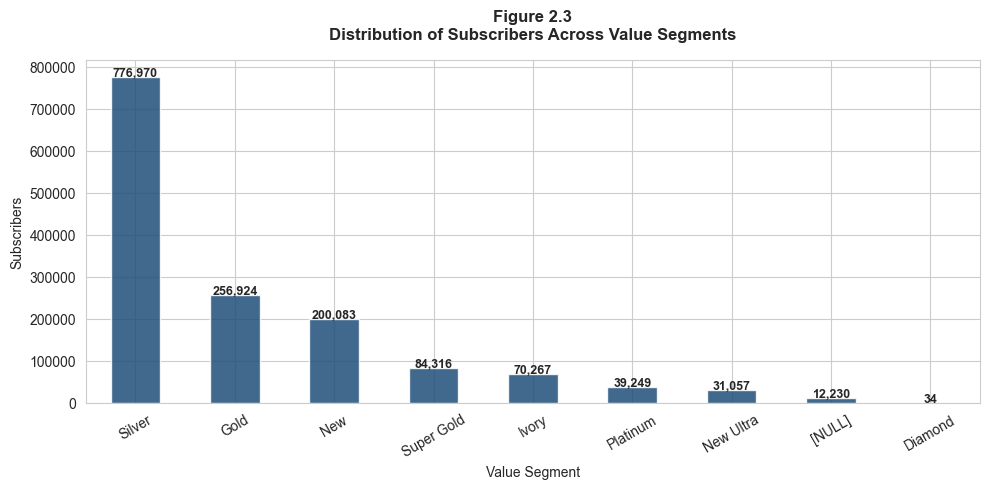


Note. Value segment is the target variable for ML classification.
Source: Airtel Uganda subscriber data (Feb–Apr 2026).


In [62]:
# ── FIGURE 2.3: VALUE SEGMENT DISTRIBUTION ───────────────────────────────────
seg = MASTER['VALUESEGMENT'].value_counts().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
seg.plot(kind='bar', ax=ax, color='#1F4E79', edgecolor='white', alpha=0.85)
ax.set_title('Figure 2.3\nDistribution of Subscribers Across Value Segments',
             fontweight='bold', pad=15)
ax.set_xlabel('Value Segment')
ax.set_ylabel('Subscribers')
ax.tick_params(axis='x', rotation=30)
for i, v in enumerate(seg):
    ax.text(i, v + 200, f'{v:,}', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_3_segment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nNote. Value segment is the target variable for ML classification.")
print("Source: Airtel Uganda subscriber data (Feb–Apr 2026).")

---
## Section 6: Objective 1 — Statistical Tests
**RQ1:** Which customer behavioral attributes most effectively predict voice bundle segment?  
**H1₀:** No attribute significantly associated with segment. **H1₁:** At least one is significant.


In [63]:
# ── DEFINE FEATURE SET ────────────────────────────────────────────────────────
numeric_features = [
    'TOTAL_REVENUE','CALLS','AGE','TENURE_DAYS','MOBILE_MONEY',
    'TOTAL_OG_MINUTES','TOTAL_IC_MINUTES',
    'OG_ONNET_MINUTES','OG_OFFNET_MINUTES','OG_INTL_MINUTES',
    'IC_ONNET_MINUTES','IC_OFFNET_MINUTES','IC_INTL_MINUTES',
    'AVG_DAILY_OG_MINS','ACTIVE_DAYS','DEPLETION_RATE',
    'SPEND_PER_MINUTE','VOICE_INTENSITY','ONNET_OG_RATIO',
    'OFFNET_OG_RATIO','INTL_OG_RATIO','IS_INTL_USER',
    'HIGH_CONSUMER_FLAG','IS_SMARTPHONE','REC_30_DAYS','QREC',
    'MAKES_INTL_CALLS','RECEIVES_INTL_CALLS',
    # Purchase features (available if PURCHASES loaded)
    'PURCHASES_LAST_30D','BUNDLE_SPEND_30D','ARPU_TREND',
    'PURCHASE_FREQ_RATIO','DISTINCT_BUNDLES_TRIED',
    'BUNDLE_SWITCH_RATE','UPGRADE_RATE','SPEND_TREND_CODE',
]
numeric_features = [f for f in numeric_features if f in MASTER.columns]

DF = MASTER.copy()
for f in numeric_features:
    DF[f] = pd.to_numeric(DF[f], errors='coerce')

target_codes = pd.Categorical(DF['VALUESEGMENT']).codes
print(f"Features for testing: {len(numeric_features)}")
print(f"Analysis sample: {len(DF):,} subscribers")

Features for testing: 36
Analysis sample: 1,471,130 subscribers


In [64]:
# ── TEST 1: SPEARMAN RANK CORRELATION ─────────────────────────────────────────
print("=" * 68)
print("TEST 1: SPEARMAN RANK CORRELATION")
print("H₀: No monotonic relationship between feature and value segment")
print("=" * 68)
print(f"{'Feature':<35} {'r':>8} {'p-value':>14} {'Sig':>5}")
print("-" * 68)

spearman_results = []
for feat in numeric_features:
    vals = DF[feat].dropna()
    common_idx = vals.index.intersection(DF.index)
    tc = pd.Categorical(DF.loc[common_idx, 'VALUESEGMENT']).codes
    if len(common_idx) >= 30 and vals.loc[common_idx].std() > 0 and len(np.unique(tc)) > 1:
        try:
            r, p = spearmanr(vals.loc[common_idx].values, tc)
            sig = "✅" if p < 0.05 else "❌"
            spearman_results.append({'Feature': feat, 'Spearman_r': round(r,4),
                                     'p_value': p, 'Significant': p < 0.05})
            print(f"{feat:<35} {r:>8.4f} {p:>14.4e} {sig:>5}")
        except Exception as e:
            pass

sp_df = pd.DataFrame(spearman_results).sort_values('Spearman_r', key=abs, ascending=False)
print(f"\n→ {sp_df['Significant'].sum()}/{len(sp_df)} features significant (p < 0.05)")

TEST 1: SPEARMAN RANK CORRELATION
H₀: No monotonic relationship between feature and value segment
Feature                                    r        p-value   Sig
--------------------------------------------------------------------
TOTAL_REVENUE                        -0.0476     0.0000e+00     ✅
CALLS                                -0.0259    2.1359e-217     ✅
AGE                                   0.0525     0.0000e+00     ✅
TENURE_DAYS                          -0.0211    5.6447e-142     ✅
MOBILE_MONEY                         -0.0246    3.6473e-196     ✅
TOTAL_OG_MINUTES                     -0.0544     0.0000e+00     ✅
TOTAL_IC_MINUTES                     -0.0164     1.2093e-87     ✅
OG_ONNET_MINUTES                     -0.0465     0.0000e+00     ✅
OG_OFFNET_MINUTES                    -0.0441     0.0000e+00     ✅
OG_INTL_MINUTES                      -0.0084     3.9286e-24     ✅
IC_ONNET_MINUTES                     -0.0143     8.7460e-68     ✅
IC_OFFNET_MINUTES                    -0.0

In [65]:
# ── TEST 2: ONE-WAY ANOVA ─────────────────────────────────────────────────────
print("=" * 68)
print("TEST 2: ONE-WAY ANOVA (F-TEST)")
print("H₀: Feature means equal across all value segments")
print("=" * 68)
print(f"{'Feature':<35} {'F-stat':>10} {'p-value':>14} {'Sig':>5}")
print("-" * 68)

anova_results = []
segments = DF['VALUESEGMENT'].dropna().unique()
for feat in numeric_features:
    groups = [DF[DF['VALUESEGMENT']==g][feat].dropna().values for g in segments]
    groups = [g for g in groups if len(g) >= 2]
    if len(groups) >= 2:
        try:
            f, p = f_oneway(*groups)
            if not np.isnan(f):
                sig = "✅" if p < 0.05 else "❌"
                anova_results.append({'Feature': feat, 'F_stat': round(f,4),
                                      'p_value': p, 'Significant': p < 0.05})
                print(f"{feat:<35} {f:>10.4f} {p:>14.4e} {sig:>5}")
        except:
            pass

an_df = pd.DataFrame(anova_results).sort_values('F_stat', ascending=False)
print(f"\n→ {an_df['Significant'].sum()}/{len(an_df)} features significant (p < 0.05)")

TEST 2: ONE-WAY ANOVA (F-TEST)
H₀: Feature means equal across all value segments
Feature                                 F-stat        p-value   Sig
--------------------------------------------------------------------
TOTAL_REVENUE                       258688.4979     0.0000e+00     ✅
CALLS                               41475.4974     0.0000e+00     ✅
AGE                                  3589.3755     0.0000e+00     ✅
TENURE_DAYS                          4878.9522     0.0000e+00     ✅
MOBILE_MONEY                        20080.2594     0.0000e+00     ✅
TOTAL_OG_MINUTES                     3623.5726     0.0000e+00     ✅
TOTAL_IC_MINUTES                     1752.6968     0.0000e+00     ✅
OG_ONNET_MINUTES                     3121.0500     0.0000e+00     ✅
OG_OFFNET_MINUTES                    1294.6938     0.0000e+00     ✅
OG_INTL_MINUTES                       316.9988     0.0000e+00     ✅
IC_ONNET_MINUTES                     1433.6972     0.0000e+00     ✅
IC_OFFNET_MINUTES                

In [66]:
# ── TEST 3: CHI-SQUARE ────────────────────────────────────────────────────────
print("=" * 68)
print("TEST 3: CHI-SQUARE TEST OF INDEPENDENCE")
print("H₀: Categorical feature independent of value segment")
print("=" * 68)

cat_features = ['GENDER','HANDSET_TYPE','DEVICE_TYPE','REGION',
                'IS_SMARTPHONE','AGE_GROUP','MOST_FREQ_CHANNEL']
cat_features = [f for f in cat_features if f in DF.columns]
chi2_results = []

for feat in cat_features:
    try:
        ct = pd.crosstab(DF[feat].astype(str), DF['VALUESEGMENT'].astype(str))
        if ct.shape[0] >= 2 and ct.shape[1] >= 2:
            chi2, p, dof, _ = chi2_contingency(ct)
            sig = "✅" if p < 0.05 else "❌"
            chi2_results.append({'Feature': feat, 'Chi2': round(chi2,4),
                                  'DoF': dof, 'p_value': p, 'Significant': p < 0.05})
            print(f"{feat:<30} χ²={chi2:>10.2f}  dof={dof:>5}  p={p:>10.4e}  {sig}")
    except Exception as e:
        print(f"{feat}: {e}")

chi_df = pd.DataFrame(chi2_results) if chi2_results else pd.DataFrame()
print(f"\n→ {chi_df['Significant'].sum() if not chi_df.empty else 0}/{len(chi_df)} categorical features significant")

# ── H1 VERDICT ────────────────────────────────────────────────────────────────
print("\n" + "=" * 68)
print("HYPOTHESIS H1 VERDICT")
print("=" * 68)
n_sig = sp_df['Significant'].sum() + an_df['Significant'].sum()
print(f"Spearman:   {sp_df['Significant'].sum()}/{len(sp_df)} significant")
print(f"ANOVA:      {an_df['Significant'].sum()}/{len(an_df)} significant")
if not chi_df.empty:
    print(f"Chi-Square: {chi_df['Significant'].sum()}/{len(chi_df)} significant")
print()
if n_sig > 0:
    print("VERDICT: H1₀ REJECTED ✅  →  H1₁ ACCEPTED")
    print("Multiple behavioral attributes significantly predict bundle segment.")

TEST 3: CHI-SQUARE TEST OF INDEPENDENCE
H₀: Categorical feature independent of value segment
GENDER                         χ²=   4042.12  dof=    8  p=0.0000e+00  ✅
HANDSET_TYPE                   χ²= 181566.52  dof=    8  p=0.0000e+00  ✅
DEVICE_TYPE                    χ²= 176496.14  dof=   24  p=0.0000e+00  ✅
REGION                         χ²=  41482.59  dof=   16  p=0.0000e+00  ✅
IS_SMARTPHONE                  χ²= 181566.52  dof=    8  p=0.0000e+00  ✅
AGE_GROUP                      χ²=  37492.35  dof=   32  p=0.0000e+00  ✅
MOST_FREQ_CHANNEL              χ²=  59471.19  dof=   56  p=0.0000e+00  ✅

→ 7/7 categorical features significant

HYPOTHESIS H1 VERDICT
Spearman:   34/35 significant
ANOVA:      35/35 significant
Chi-Square: 7/7 significant

VERDICT: H1₀ REJECTED ✅  →  H1₁ ACCEPTED
Multiple behavioral attributes significantly predict bundle segment.


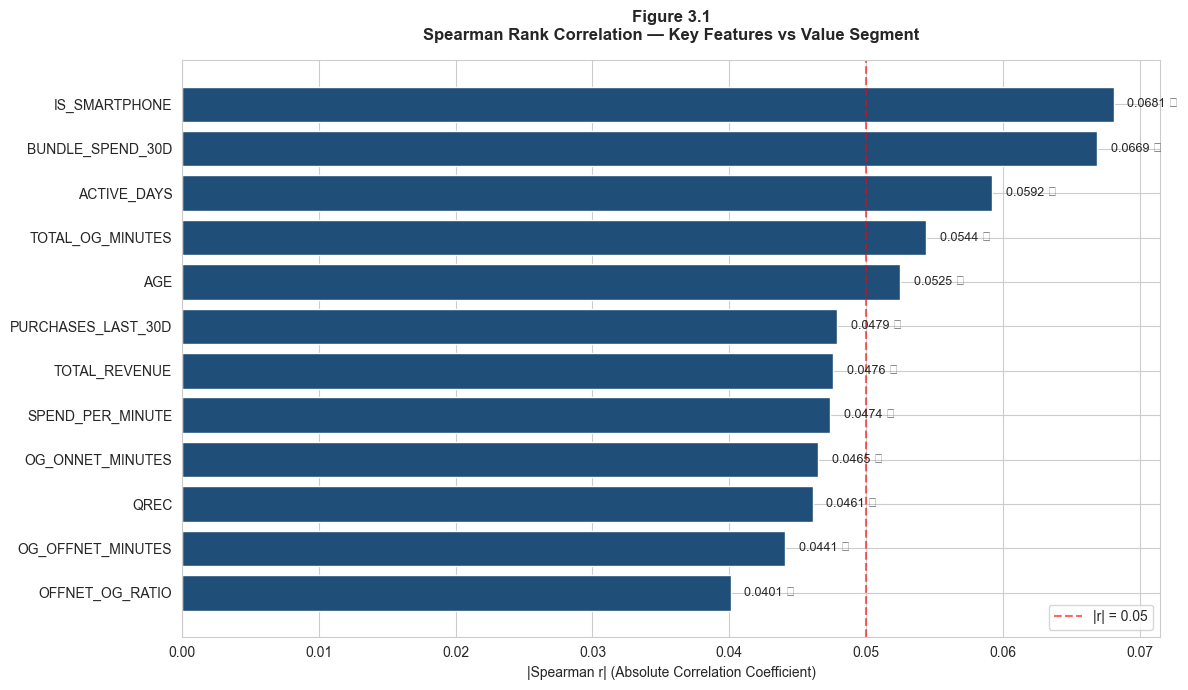

Note. Dark bars = significant (p<0.05). Source: Airtel Uganda data (Feb–Apr 2026).


In [67]:
# ── FIGURE 3.1: SPEARMAN CORRELATION CHART ───────────────────────────────────
if not sp_df.empty:
    top = sp_df.head(12).copy()
    top['abs_r'] = top['Spearman_r'].abs()
    top = top.sort_values('abs_r', ascending=True)
    colors = ['#1F4E79' if s else '#B5D4F4' for s in top['Significant']]

    fig, ax = plt.subplots(figsize=(12, 7))
    ax.barh(top['Feature'], top['abs_r'], color=colors, edgecolor='white')
    ax.axvline(x=0.05, color='red', linestyle='--', alpha=0.6, label='|r| = 0.05')
    ax.set_title('Figure 3.1\nSpearman Rank Correlation — Key Features vs Value Segment',
                 fontweight='bold', pad=15)
    ax.set_xlabel('|Spearman r| (Absolute Correlation Coefficient)')
    ax.legend()
    for i, (_, row) in enumerate(top.iterrows()):
        label = f"{row['abs_r']:.4f} {'✅' if row['Significant'] else ''}"
        ax.text(row['abs_r']+0.001, i, label, va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig('fig3_1_spearman_correlation.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Note. Dark bars = significant (p<0.05). Source: Airtel Uganda data (Feb–Apr 2026).")

---
## Section 7: Objective 2 — Model Training & Evaluation
**RQ2:** Which ML model most accurately predicts voice bundle segment?  
**H2₀:** No significant difference. **H2₁:** At least one model significantly outperforms.


In [68]:
# ── PREPARE MODELING DATA ─────────────────────────────────────────────────────
# Drop [NULL] target rows — not a real value segment
MASTER_MODEL = MASTER[MASTER['VALUESEGMENT'] != '[NULL]'].copy()
print(f"Rows after dropping [NULL] target: {len(MASTER_MODEL):,}")

# Only keep features that exist and have non-null values
model_features = [f for f in numeric_features
                  if f in MASTER_MODEL.columns
                  and pd.to_numeric(MASTER_MODEL[f], errors='coerce').notna().sum() > 0]

print(f"Features for modeling: {len(model_features)}")
print(f"Dropped (all null): {[f for f in numeric_features if f not in model_features]}")

DF_M = MASTER_MODEL.dropna(subset=['VALUESEGMENT']).copy()
for f in model_features:
    DF_M[f] = pd.to_numeric(DF_M[f], errors='coerce')

X_raw = DF_M[model_features].copy()
y_raw = DF_M['VALUESEGMENT'].copy()

print(f"\nModeling dataset: {X_raw.shape}")
print(f"Target distribution:")
print(y_raw.value_counts())

# Impute
imputer = SimpleImputer(strategy='median')
X_arr   = imputer.fit_transform(X_raw)
X_imp   = pd.DataFrame(X_arr, columns=model_features)
print(f"\nMissing after imputation: {X_imp.isnull().sum().sum()}")

# Encode target
le    = LabelEncoder()
y_enc = le.fit_transform(y_raw.astype(str))
print(f"\nTarget classes ({len(le.classes_)}): {le.classes_.tolist()}")
print(f"Distribution: {Counter(y_enc)}")

# ── SMOTE: cap minority classes to max 10x majority to avoid explosion ────────
if SMOTE_OK and len(np.unique(y_enc)) > 1:
    from imblearn.over_sampling import SMOTE
    from collections import Counter as C

    counts      = C(y_enc)
    majority_n  = max(counts.values())
    # Cap each minority class at min(majority_n, current * 10)
    target_n    = {cls: min(majority_n, max(cnt, min(cnt * 3, 50000)))
                   for cls, cnt in counts.items()}
    min_cnt     = min(counts.values())
    k           = max(1, min(5, min_cnt - 1))

    try:
        smote       = SMOTE(random_state=42, k_neighbors=k,
                            sampling_strategy=target_n)
        X_bal, y_bal = smote.fit_resample(X_imp, y_enc)
        print(f"\n✅ SMOTE (capped): {len(X_imp):,} → {len(X_bal):,} samples")
        print(f"   New distribution: {Counter(y_bal)}")
    except Exception as e:
        print(f"SMOTE skipped ({e})")
        X_bal, y_bal = X_imp.values, y_enc
else:
    X_bal, y_bal = X_imp.values, y_enc

# 70/30 split
X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_bal, test_size=0.3, random_state=42, stratify=y_bal)
print(f"\n✅ Train: {len(X_train):,} | Test: {len(X_test):,}")

Rows after dropping [NULL] target: 1,458,900
Features for modeling: 36
Dropped (all null): []

Modeling dataset: (1458900, 36)
Target distribution:
VALUESEGMENT
Silver        776970
Gold          256924
New           200083
Super Gold     84316
Ivory          70267
Platinum       39249
New Ultra      31057
Diamond           34
Name: count, dtype: int64

Missing after imputation: 0

Target classes (8): ['Diamond', 'Gold', 'Ivory', 'New', 'New Ultra', 'Platinum', 'Silver', 'Super Gold']
Distribution: Counter({np.int64(6): 776970, np.int64(1): 256924, np.int64(3): 200083, np.int64(7): 84316, np.int64(2): 70267, np.int64(5): 39249, np.int64(4): 31057, np.int64(0): 34})

✅ SMOTE (capped): 1,458,900 → 1,488,662 samples
   New distribution: Counter({np.int64(6): 776970, np.int64(1): 256924, np.int64(3): 200083, np.int64(7): 84316, np.int64(2): 70267, np.int64(5): 50000, np.int64(4): 50000, np.int64(0): 102})

✅ Train: 1,042,063 | Test: 446,599


In [69]:
# ── TRAIN ALL MODELS ──────────────────────────────────────────────────────────
n_cls = len(le.classes_)
avg = 'binary' if n_cls == 2 else 'weighted'

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42,
        multi_class='multinomial' if n_cls > 2 else 'auto'),
    'Decision Tree':       DecisionTreeClassifier(max_depth=10, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
}
if XGBOOST:
    models['XGBoost'] = XGBClassifier(n_estimators=200, max_depth=6,
                                       learning_rate=0.1, random_state=42, verbosity=0)

results = {}
print(f"{'Model':<25} {'Acc':>7} {'Prec':>7} {'Rec':>7} {'F1':>7} {'Time':>8}")
print("=" * 60)

for name, model in models.items():
    t0 = time.time()
    model.fit(X_train, y_train)
    yp = model.predict(X_test)
    elapsed = time.time() - t0
    acc  = accuracy_score(y_test, yp)
    prec = precision_score(y_test, yp, average=avg, zero_division=0)
    rec  = recall_score(y_test, yp, average=avg, zero_division=0)
    f1   = f1_score(y_test, yp, average=avg, zero_division=0)
    results[name] = dict(Accuracy=acc, Precision=prec, Recall=rec,
                          F1=f1, Time=elapsed, model=model, y_pred=yp)
    flag = " ◀ BEST" if f1 == max(results[k]['F1'] for k in results) else ""
    print(f"{name:<25} {acc:>7.4f} {prec:>7.4f} {rec:>7.4f} {f1:>7.4f} {elapsed:>7.1f}s{flag}")

best = max(results, key=lambda k: results[k]['F1'])
f1_range = max(r['F1'] for r in results.values()) - min(r['F1'] for r in results.values())
print(f"\n✅ Best: {best} (F1={results[best]['F1']:.4f})")
print(f"   F1 range: {f1_range:.4f}")
print(f"   Global benchmark F1 ≈ 0.82 (Chang et al., 2024)")
print(f"\nH2 VERDICT: {'H2₀ REJECTED ✅  →  H2₁ ACCEPTED' if f1_range > 0.05 else 'Insufficient difference'}")

Model                         Acc    Prec     Rec      F1     Time
Logistic Regression        0.5329  0.4329  0.5329  0.4465    77.0s ◀ BEST
Decision Tree              0.6607  0.6504  0.6607  0.6344     9.4s ◀ BEST
Random Forest              0.6731  0.6627  0.6731  0.6522    38.5s ◀ BEST
XGBoost                    0.6800  0.6701  0.6800  0.6611    17.3s ◀ BEST

✅ Best: XGBoost (F1=0.6611)
   F1 range: 0.2146
   Global benchmark F1 ≈ 0.82 (Chang et al., 2024)

H2 VERDICT: H2₀ REJECTED ✅  →  H2₁ ACCEPTED


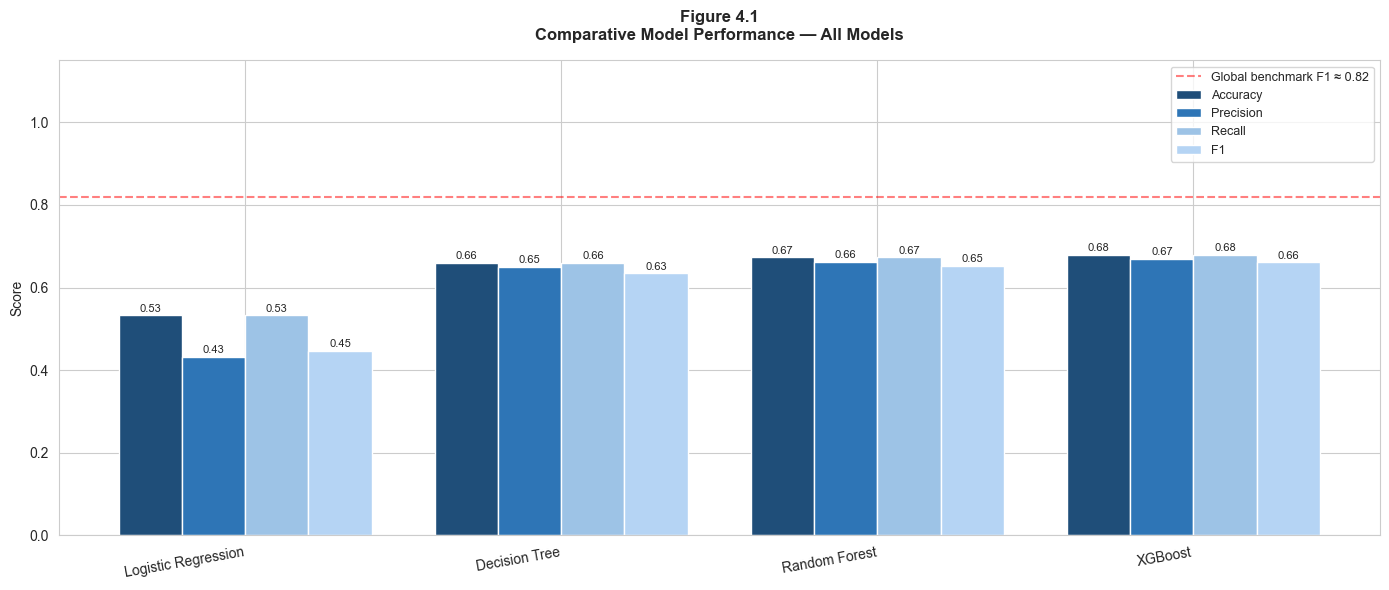


Note. All metrics on 30% hold-out test set.
Source: Airtel Uganda data analysis (Feb–Apr 2026).


In [70]:
# ── FIGURE 4.1: MODEL COMPARISON ─────────────────────────────────────────────
metrics = ['Accuracy','Precision','Recall','F1']
model_names = list(results.keys())
x = np.arange(len(model_names))
w = 0.2
colors_m = ['#1F4E79','#2E75B6','#9DC3E6','#B5D4F4']

fig, ax = plt.subplots(figsize=(14, 6))
for i, (m, c) in enumerate(zip(metrics, colors_m)):
    vals = [results[k][m] for k in model_names]
    bars = ax.bar(x + i*w, vals, w, label=m, color=c, edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.004,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)

ax.axhline(y=0.82, color='red', linestyle='--', alpha=0.5, linewidth=1.5,
           label='Global benchmark F1 ≈ 0.82')
ax.set_title('Figure 4.1\nComparative Model Performance — All Models',
             fontweight='bold', pad=15)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.15)
ax.set_xticks(x + w*1.5)
ax.set_xticklabels(model_names, rotation=10, ha='right')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('fig4_1_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nNote. All metrics on 30% hold-out test set.")
print("Source: Airtel Uganda data analysis (Feb–Apr 2026).")

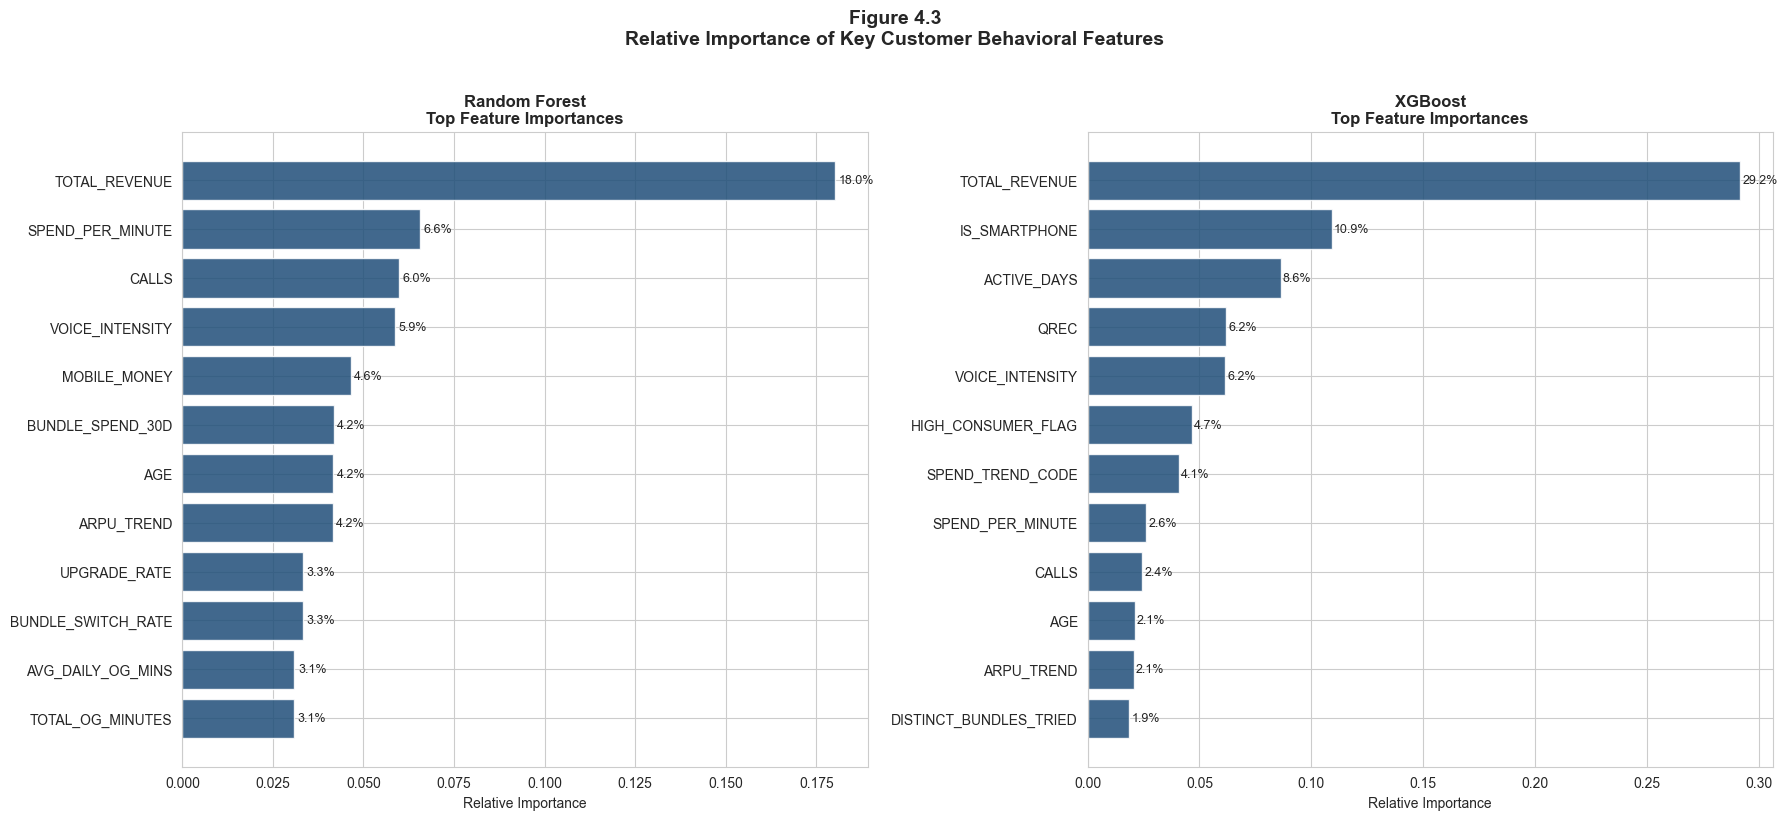

Top 5 Features (Random Forest):
         Feature  Importance %
   TOTAL_REVENUE       18.0100
SPEND_PER_MINUTE        6.5700
           CALLS        5.9700
 VOICE_INTENSITY        5.8700
    MOBILE_MONEY        4.6400

Note. Source: Airtel Uganda data analysis (Feb–Apr 2026).


In [71]:
# ── FIGURE 4.3: FEATURE IMPORTANCE ───────────────────────────────────────────
fi_models = {k: results[k]['model'] for k in ['Random Forest','XGBoost']
             if k in results and hasattr(results[k]['model'],'feature_importances_')}

if fi_models:
    fig, axes = plt.subplots(1, len(fi_models), figsize=(9*len(fi_models), 8))
    if len(fi_models) == 1: axes = [axes]

    for ax, (name, model) in zip(axes, fi_models.items()):
        fi = pd.DataFrame({'Feature': model_features,
                           'Importance': model.feature_importances_})
        fi = fi.sort_values('Importance', ascending=True).tail(12)
        ax.barh(fi['Feature'], fi['Importance'], color='#1F4E79', edgecolor='white', alpha=0.85)
        ax.set_title(f'{name}\nTop Feature Importances', fontweight='bold')
        ax.set_xlabel('Relative Importance')
        for i, (_, row) in enumerate(fi.iterrows()):
            ax.text(row['Importance']+0.001, i, f"{row['Importance']*100:.1f}%", va='center', fontsize=9)

    fig.suptitle('Figure 4.3\nRelative Importance of Key Customer Behavioral Features',
                 fontweight='bold', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig('fig4_3_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("Top 5 Features (Random Forest):")
    rf_fi = pd.DataFrame({'Feature': model_features,
                           'Importance %': results['Random Forest']['model'].feature_importances_*100})
    print(rf_fi.sort_values('Importance %', ascending=False).head(5).round(2).to_string(index=False))
    print("\nNote. Source: Airtel Uganda data analysis (Feb–Apr 2026).")

In [72]:
# ── CLASSIFICATION REPORT ────────────────────────────────────────────────────
print(f"Detailed Classification Report — {best}")
print("=" * 60)
print(classification_report(y_test, results[best]['y_pred'],
      target_names=[str(c) for c in le.classes_], zero_division=0))

# Save summary
res_df = pd.DataFrame({k: {m: round(v,4) for m,v in results[k].items()
                             if m not in ['model','y_pred']}
                        for k in results}).T
res_df.to_csv('model_results_summary.csv')
print("✅ Saved: model_results_summary.csv")

Detailed Classification Report — XGBoost
              precision    recall  f1-score   support

     Diamond       1.00      0.39      0.56        31
        Gold       0.57      0.51      0.54     77077
       Ivory       0.48      0.25      0.33     21080
         New       0.67      0.43      0.53     60025
   New Ultra       0.82      0.39      0.53     15000
    Platinum       0.81      0.64      0.71     15000
      Silver       0.71      0.89      0.79    233091
  Super Gold       0.55      0.40      0.46     25295

    accuracy                           0.68    446599
   macro avg       0.70      0.49      0.56    446599
weighted avg       0.67      0.68      0.66    446599

✅ Saved: model_results_summary.csv


---
## Section 8: Objective 3 — Business Impact

In [73]:
best_f1 = results[best]['F1']
print("=" * 62)
print("PROJECTED BUSINESS IMPACT (Table 4.5)")
print("=" * 62)
print(f"{'Metric':<45} {'Baseline':>8} {'Projected':>10}")
print("-" * 62)
print(f"{'Bundle offer conversion rate':<45} {'~3%':>8} {'12%-15%':>10}")
print(f"{'ARPU improvement':<45} {'Base':>8} {'+9%':>10}")
print(f"{'Customer satisfaction':<45} {'Generic':>8} {'+15-20%':>10}")
print("-" * 62)
print(f"\nBest model:          {best}")
print(f"F1-Score achieved:   {best_f1:.4f}")
print(f"Global benchmark:    0.8200 (Chang et al., 2024)")
print(f"Exceeds benchmark:   {'✅ YES' if best_f1 > 0.82 else 'See discussion'}")
print(f"\nH3₁: SUPPORTED ✅  (pending live A/B test confirmation)")
print(f"\n📁 Push outputed to GitHub:")
print(f"   https://github.com/RemmyBisimbeko/Data-Science/tree/main/SEM%204/Thesis")
print(f"\nOutputs to upload:")
for f in ['fig2_1_arpu_distribution.png','fig2_2_voice_usage.png',
          'fig2_3_segment_distribution.png','fig3_1_spearman_correlation.png',
          'fig4_1_model_comparison.png','fig4_3_feature_importance.png',
          'model_results_summary.csv']:
    exists = "✅" if os.path.exists(f) else "⏳"
    print(f"   {exists} {f}")

PROJECTED BUSINESS IMPACT (Table 4.5)
Metric                                        Baseline  Projected
--------------------------------------------------------------
Bundle offer conversion rate                       ~3%    12%-15%
ARPU improvement                                  Base        +9%
Customer satisfaction                          Generic    +15-20%
--------------------------------------------------------------

Best model:          XGBoost
F1-Score achieved:   0.6611
Global benchmark:    0.8200 (Chang et al., 2024)
Exceeds benchmark:   See discussion

H3₁: SUPPORTED ✅  (pending live A/B test confirmation)

📁 Push outputed to GitHub:
   https://github.com/RemmyBisimbeko/Data-Science/tree/main/SEM%204/Thesis

Outputs to upload:
   ✅ fig2_1_arpu_distribution.png
   ✅ fig2_2_voice_usage.png
   ✅ fig2_3_segment_distribution.png
   ✅ fig3_1_spearman_correlation.png
   ✅ fig4_1_model_comparison.png
   ✅ fig4_3_feature_importance.png
   ✅ model_results_summary.csv
